In [2]:
import pandas as pd
from sqlalchemy import create_engine 

username = "root" 
password = "minder" 
host = "localhost:3306" 
database = "projects" 

engine = create_engine(f"mysql+pymysql://{"root"}:{"minder"}@{"localhost:3306"}/{"projects"}")

connection = engine.connect() 
print("MySQL Connected Successfully!")

MySQL Connected Successfully!


In [3]:
query = "SELECT * FROM sample_superstore" 
df = pd.read_sql(query, engine) 

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.describe

<bound method NDFrame.describe of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9689    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9690    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9691    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9692    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9693    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520    

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9694 entries, 0 to 9693
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9694 non-null   int64  
 1   Order ID       9694 non-null   object 
 2   Order Date     9694 non-null   object 
 3   Ship Date      9694 non-null   object 
 4   Ship Mode      9694 non-null   object 
 5   Customer ID    9694 non-null   object 
 6   Customer Name  9694 non-null   object 
 7   Segment        9694 non-null   object 
 8   Country        9694 non-null   object 
 9   City           9694 non-null   object 
 10  State          9694 non-null   object 
 11  Postal Code    9694 non-null   int64  
 12  Region         9694 non-null   object 
 13  Product ID     9694 non-null   object 
 14  Category       9694 non-null   object 
 15  Sub-Category   9694 non-null   object 
 16  Product Name   9694 non-null   object 
 17  Sales          9694 non-null   float64
 18  Quantity

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [8]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015


In [9]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%m/%d/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%m/%d/%Y"
)

In [10]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [11]:
df["Order Date"].dt.strftime("%d/%m/%Y")

0       08/11/2016
1       08/11/2016
2       12/06/2016
3       11/10/2015
4       11/10/2015
           ...    
9689    21/01/2014
9690    26/02/2017
9691    26/02/2017
9692    26/02/2017
9693    04/05/2017
Name: Order Date, Length: 9694, dtype: object

In [12]:
df["Ship Date"].dt.strftime("%d/%m/%Y")

0       11/11/2016
1       11/11/2016
2       16/06/2016
3       18/10/2015
4       18/10/2015
           ...    
9689    23/01/2014
9690    03/03/2017
9691    03/03/2017
9692    03/03/2017
9693    09/05/2017
Name: Ship Date, Length: 9694, dtype: object

In [13]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [17]:
pd.crosstab(
    df["Category"],
    df["Discount"],
    values=df["Profit"],
    aggfunc="sum"
)

Discount,0.00,0.10,0.15,0.20,0.30,0.32,0.40,0.45,0.50,0.60,0.70,0.80
Category,,,,,,,,,,,,
Furniture,56532.6096,7111.0119,1418.9915,5999.6587,-10695.3169,-2391.1377,-16187.3968,-2493.1111,-12871.1990,-5548.3996,-3894.9394,NaN
Office Supplies,128329.0720,1086.0808,NaN,37380.4420,NaN,NaN,NaN,NaN,NaN,NaN,-16169.4636,-30136.2448
Technology,132322.3627,832.0843,NaN,45999.2035,326.0395,NaN,-6878.0452,NaN,-7635.2291,NaN,-19579.3191,NaN


In [18]:
df.groupby("Category")["Profit"].sum().round(2)

Category
Furniture           16980.77
Office Supplies    120489.89
Technology         145387.10
Name: Profit, dtype: float64

In [19]:
df.groupby("Segment")["Sales"].sum().round(2)

Segment
Consumer       1150166.18
Corporate       696604.51
Home Office     425679.16
Name: Sales, dtype: float64

In [20]:
df.groupby("Region")[["Sales","Profit"]].sum().round(2).sort_values(by="Sales",ascending=False)

,Sales,Profit
Region,,
West,713471.34,106021.15
East,672194.05,90672.01
Central,497800.87,40128.90
South,388983.58,46035.69


In [21]:
df.groupby("Category").agg({"Discount":"mean","Profit":"sum"}).sort_values(by="Discount",ascending=False)

,Discount,Profit
Category,,
Furniture,0.174392,16980.7712
Office Supplies,0.155561,120489.8864
Technology,0.132246,145387.0966


In [22]:
df.to_csv(r"C:\Users\hp\Desktop\FILES\sample_superstore.csv",index=False)

In [23]:
import os

os.path.exists(r"C:\Users\hp\Desktop\FILES\sample_superstore.csv")

True

In [24]:
# Sales by Category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         835900.0670
Furniture          733046.8613
Office Supplies    703502.9280
Name: Sales, dtype: float64

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

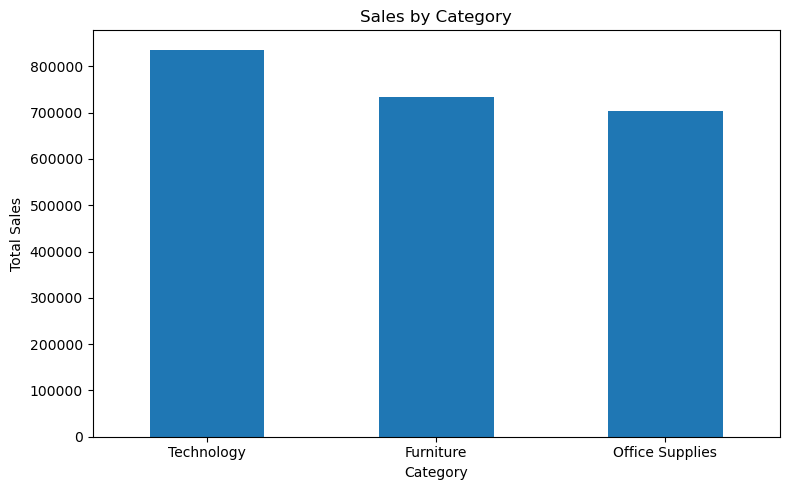

In [27]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# Profit by Category

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145387.0966
Office Supplies    120489.8864
Furniture           16980.7712
Name: Profit, dtype: float64

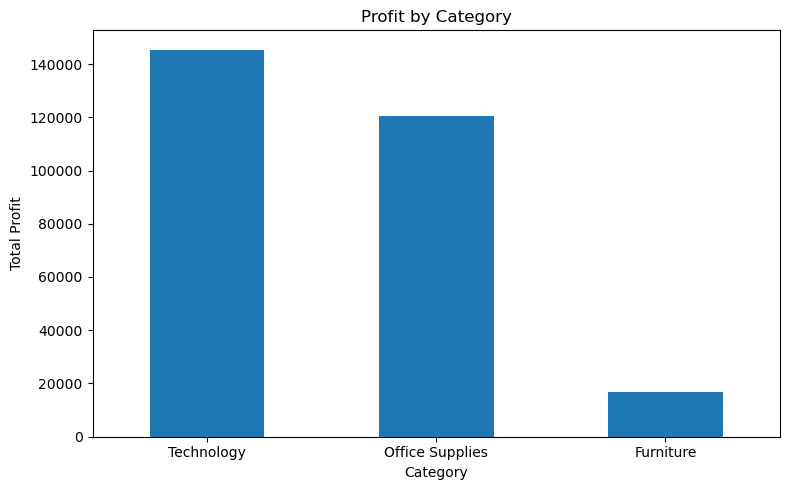

In [30]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [31]:
# Profit by Sub-Category

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

subcategory_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1348.5655
Fasteners        942.4378
Machines        3384.7569
Labels          5546.2540
Envelopes       6460.8691
Art             6527.7870
Furnishings    11588.6420
Appliances     18138.0054
Storage        21527.9083
Chairs         26590.1663
Binders        29983.0213
Paper          32712.1690
Accessories    41936.6357
Phones         44447.8791
Copiers        55617.8249
Name: Profit, dtype: float64

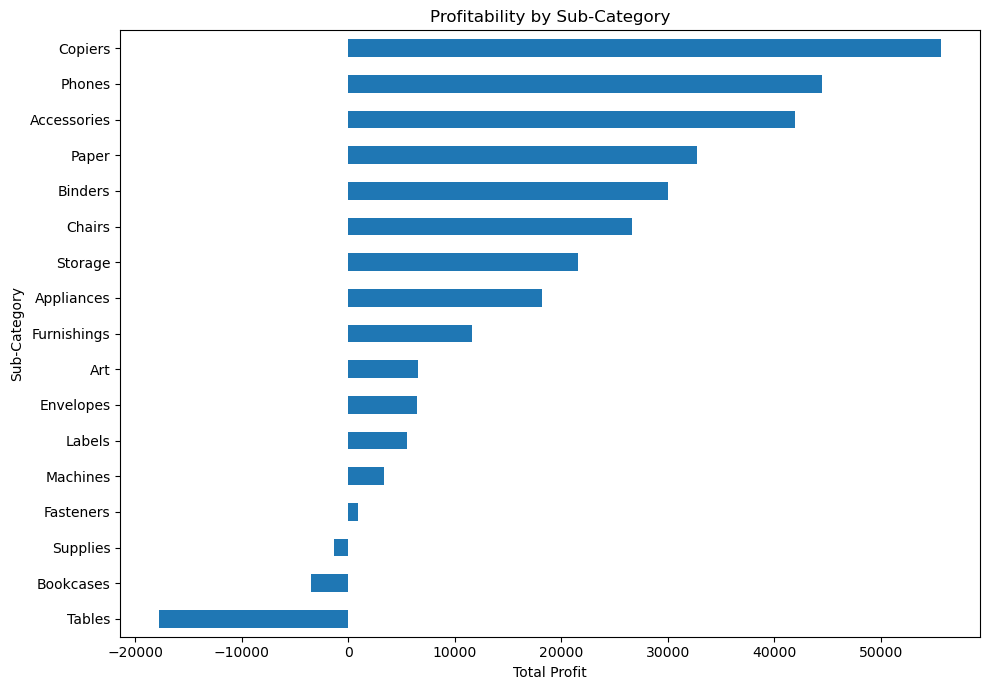

In [32]:
plt.figure(figsize=(10, 7))

subcategory_profit.plot(kind="barh")

plt.title("Profitability by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [33]:
# Sales by Region

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales


Region
West       713471.3445
East       672194.0540
Central    497800.8728
South      388983.5850
Name: Sales, dtype: float64

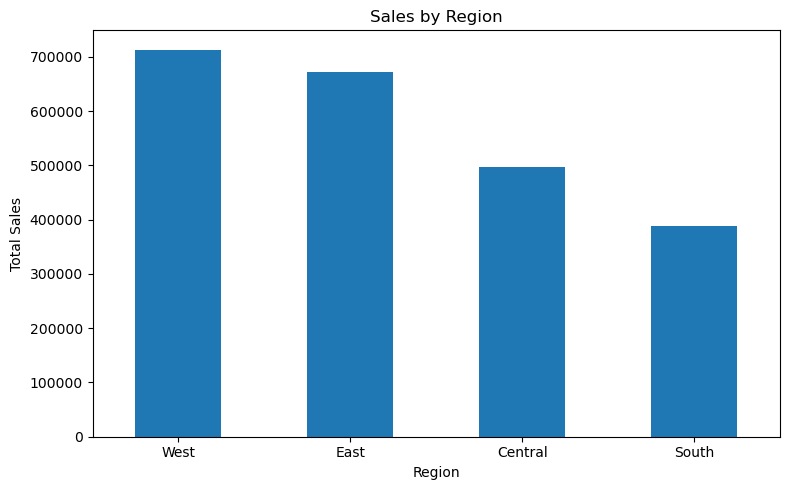

In [34]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [35]:
# Sales by Customer Segment

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.150166e+06
Corporate      6.966045e+05
Home Office    4.256792e+05
Name: Sales, dtype: float64

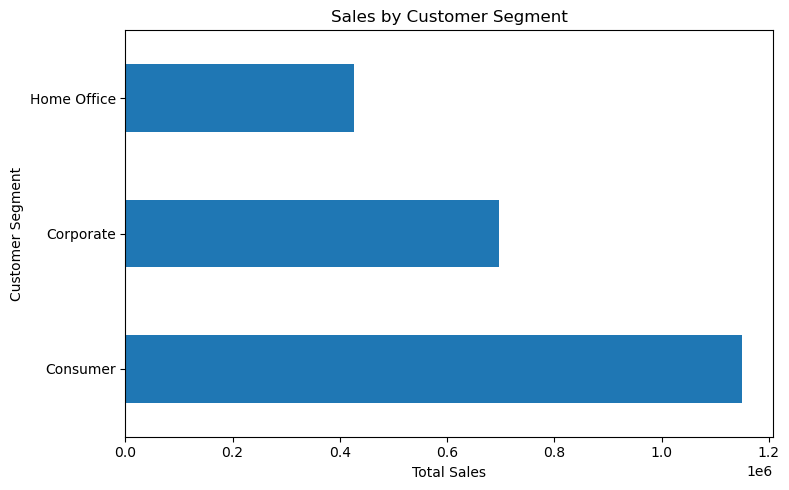

In [36]:
plt.figure(figsize=(8, 5))

segment_sales.plot(kind="barh")

plt.title("Sales by Customer Segment")
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [38]:
yearly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .sort_index()
)

yearly_sales

Order Date
2014-01-04     288.0600
2014-01-05      19.5360
2014-01-06    4407.1000
2014-01-07      87.1580
2014-01-09      40.5440
                ...    
2017-12-26     769.8440
2017-12-27     177.6360
2017-12-28    1657.3508
2017-12-29    2915.5340
2017-12-30     713.7900
Name: Sales, Length: 1232, dtype: float64

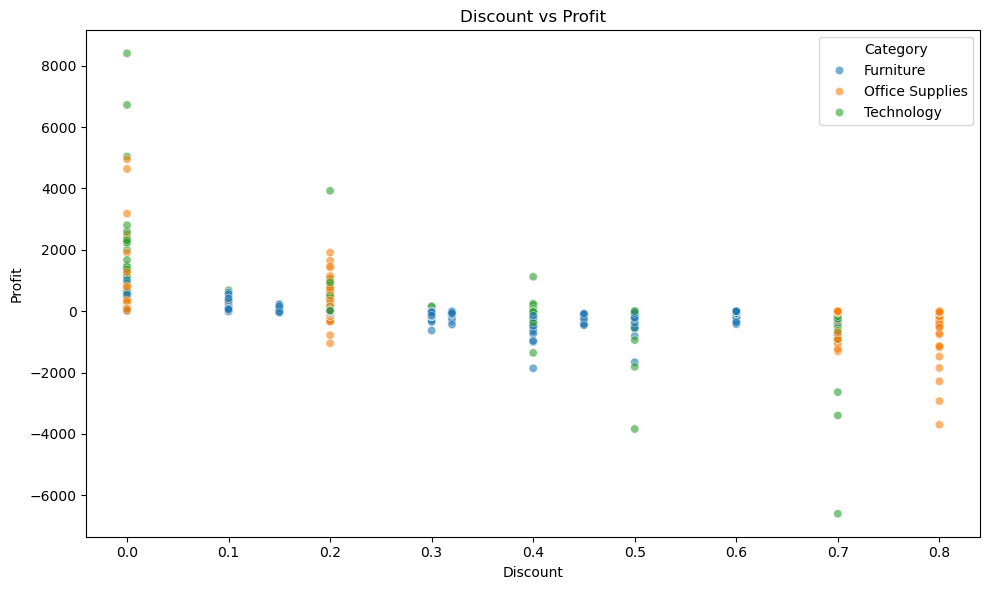

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [40]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color"                     18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

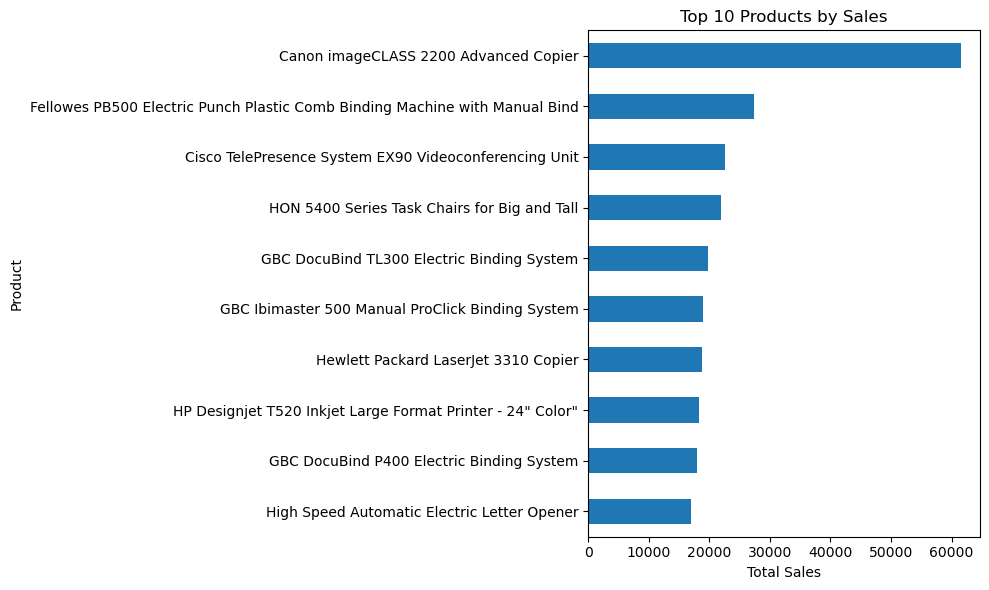

In [41]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [42]:
loss_making_subcategories = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

loss_making_subcategories[
    loss_making_subcategories < 0
]

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1348.5655
Name: Profit, dtype: float64

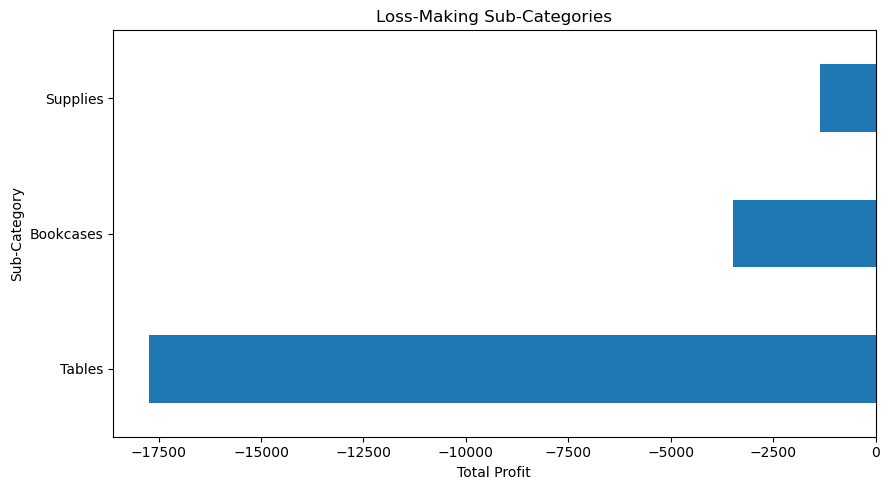

In [43]:
plt.figure(figsize=(9, 5))

loss_making_subcategories[
    loss_making_subcategories < 0
].plot(kind="barh")

plt.title("Loss-Making Sub-Categories")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [44]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
avg_discount = df["Discount"].mean()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales       : {total_sales:,.2f}")
print(f"Total Profit      : {total_profit:,.2f}")
print(f"Total Quantity    : {total_quantity:,.0f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Average Discount  : {avg_discount:.2%}")
print(f"Profit Margin     : {profit_margin:.2f}%")

Total Sales       : 2,272,449.86
Total Profit      : 282,857.75
Total Quantity    : 36,749
Total Orders      : 4,931
Average Discount  : 15.52%
Profit Margin     : 12.45%


# Key Insights

- Technology is the most profitable category.
- Furniture generates strong sales but relatively low profit.
- Tables are a major loss-making sub-category.
- The West region contributes the highest share of sales.
- Consumer is the largest customer segment by sales.
- Monthly sales show noticeable fluctuations throughout the period.
- Discount levels show a relationship with profitability in some transactions.